This notebook transforms the cleaned telecom customer dataset into meaningful analytical features that can be used to identify customer segments, measure customer engagement, and investigate characteristics associated with customer churn.

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
df = pd.read_csv("../data/processed/telco_Customer_Churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [30]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].dtype
df["TotalCharges"].isna().sum()

## Which stage of the customer lifecycle is most vulnerable to churn?

df["TenureSegment"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "New Customer (0-12 months)",
        "Early Customer (13-24 months)",
        "Established Customer (25-48 months)",
        "Long-Term Customer (49-72 months)"
    ]
)
df["TenureSegment"].value_counts()

## Which pricing segment has the highest churn?

df["MonthlyChargeSegment"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "Low ($0-$40)",
        "Medium ($41-$70)",
        "High ($71-$100)",
        "Premium ($101+)"
    ]
)
df["MonthlyChargeSegment"].value_counts()

## Service Engagement Score

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]
df["ServiceEngagementScore"] = (
    (df["OnlineSecurity"] == "Yes").astype(int)
    + (df["OnlineBackup"] == "Yes").astype(int)
    + (df["DeviceProtection"] == "Yes").astype(int)
    + (df["TechSupport"] == "Yes").astype(int)
)
df["ServiceEngagementScore"].value_counts().sort_index()

## Service Bundle Category
df["ServiceEngagementLevel"] = pd.cut(
    df["ServiceEngagementScore"],
    bins=[-1, 0, 2, 4],
    labels=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement"
    ]
)

## Contract-Tenure Segment 

df["ContractTenureSegment"] = np.where(
    (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12),
    "New Month-to-Month Customer",
    np.where(
        (df["Contract"] == "Month-to-month") & (df["tenure"] > 12),
        "Existing Month-to-Month Customer",
        np.where(
            df["Contract"] == "One year",
            "One-Year Contract Customer",
            "Two-Year Contract Customer"
        )
    )
)
df["ContractTenureSegment"].value_counts()

## High-Value Customer Flag

high_value_threshold = df["MonthlyCharges"].quantile(0.75)

high_value_threshold
df["HighValueCustomer"] = np.where(
    df["MonthlyCharges"] >= high_value_threshold,
    "Yes",
    "No"
)
df["HighValueCustomer"].value_counts()

## Does the combination of multiple churn risk factors identify a particularly vulnerable customer segment?

df["HighRiskCustomer"] = np.where(
    (
        (df["Contract"] == "Month-to-month") &
        (df["tenure"] <= 12) &
        (df["MonthlyCharges"] >= high_value_threshold) &
        (df["OnlineSecurity"] == "No") &
        (df["TechSupport"] == "No")
    ),
    "High Risk",
    "Other"
)
df["HighRiskCustomer"].value_counts()
df.groupby("HighRiskCustomer")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)


HighRiskCustomer
High Risk    82.781457
Other        25.304701
Name: Churn, dtype: float64

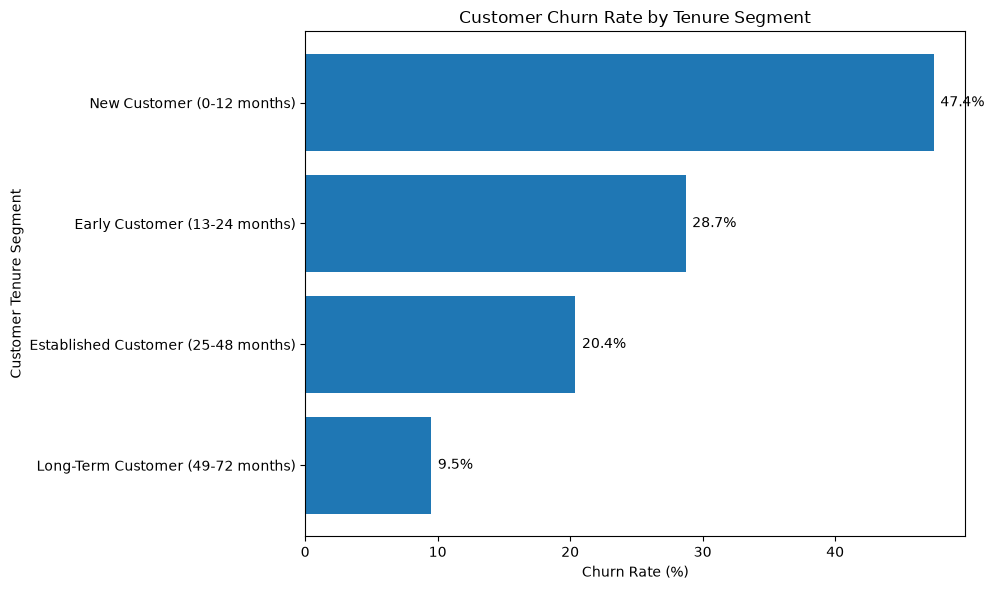

In [32]:
tenure_segment_churn = (
    df.groupby("TenureSegment", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_segment_churn
# Calculate churn rate by tenure segment
tenure_segment_churn = (
    df.groupby("TenureSegment", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values()
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    tenure_segment_churn.index,
    tenure_segment_churn.values
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Tenure Segment")
plt.title("Customer Churn Rate by Tenure Segment")

# Add percentage labels to each bar
for i, value in enumerate(tenure_segment_churn.values):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Customer Churn Rate by Tenure Segment

The analysis reveals a strong relationship between customer lifecycle stage and churn. **New customers with a tenure of 0–12 months have the highest churn rate at 47.44%**, followed by **Early Customers (13–24 months) at 28.71%**. Churn continues to decline among **Established Customers (25–48 months), with a rate of 20.39%**, while **Long-Term Customers (49–72 months) have the lowest churn rate at just 9.51%**.

The results demonstrate a clear downward trend in churn as customers remain with the company for longer periods. New customers are approximately five times more likely to churn than long-term customers, highlighting the importance of the early customer lifecycle in determining long-term retention.

### Business Insight

The first 12 months represent the company's most critical customer retention period. Almost half of customers in the New Customer segment have churned, compared with fewer than one in ten Long-Term Customers. This suggests that customers who successfully remain with the company beyond the early stages are significantly more likely to develop long-term relationships.

### Recommendation

The company should prioritize **early-stage customer retention strategies**, particularly during the first year of the customer lifecycle. Recommended initiatives include structured onboarding programs, proactive customer support, early satisfaction checks, personalized engagement, and targeted loyalty incentives.

The company should also monitor new customers closely for early signs of dissatisfaction and intervene before they reach the point of cancellation. Reducing churn during the first 12 months could have a significant impact on overall customer retention and long-term customer lifetime value.

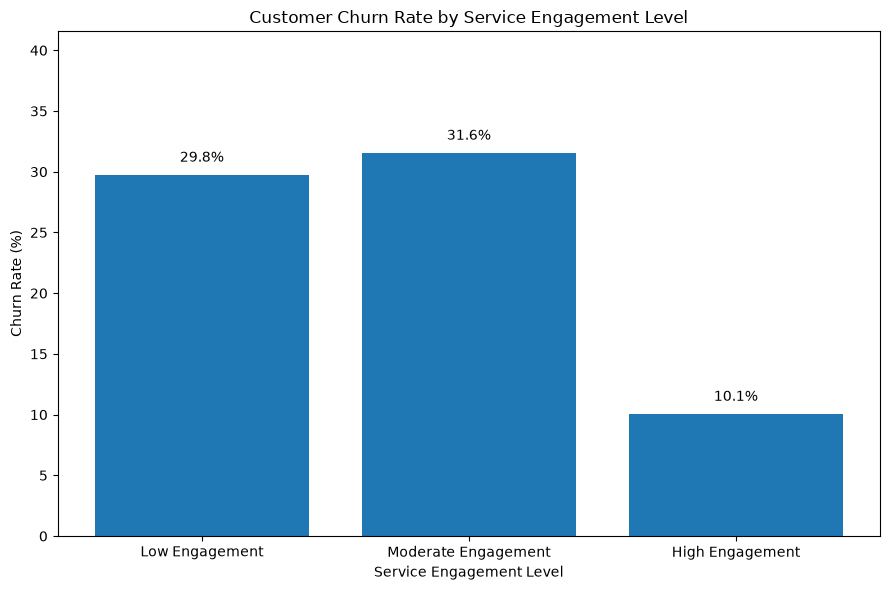

In [34]:
engagement_churn = (
    df.groupby("ServiceEngagementLevel", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

engagement_churn
# Calculate churn rate by service engagement level
engagement_churn = (
    df.groupby("ServiceEngagementLevel", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

# Create bar chart
plt.figure(figsize=(9, 6))

bars = plt.bar(
    engagement_churn.index,
    engagement_churn.values
)

plt.xlabel("Service Engagement Level")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Service Engagement Level")

# Add percentage labels above each bar
for bar, value in zip(bars, engagement_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(engagement_churn.values) + 10)
plt.tight_layout()
plt.show()

### Customer Churn Rate by Service Engagement Level

The analysis reveals a clear relationship between customer engagement with additional services and churn. Customers classified as **Moderate Engagement** have the highest churn rate at **31.56%**, followed closely by **Low Engagement** customers at **29.75%**. In contrast, customers with **High Engagement** have a substantially lower churn rate of only **10.06%**.

The results indicate that customers with high engagement are significantly less likely to churn than customers with low or moderate engagement. The churn rate among High Engagement customers is approximately three times lower than that of Moderate Engagement customers, suggesting that customers who adopt a broader range of additional services may have stronger relationships with the company.

Interestingly, the Moderate Engagement segment has a slightly higher churn rate than the Low Engagement segment. This suggests that the relationship between service adoption and churn is not completely linear. Customers who have adopted some additional services may still have unmet needs or may not perceive sufficient value from their current service combination.

### Business Insight

The findings suggest that **deeper customer engagement is associated with stronger customer retention**. Customers who use a wider range of additional services may perceive greater value from the company's overall offering and may therefore be less likely to switch to competitors.

The high churn rate among Moderate Engagement customers also presents an opportunity for further investigation. The company should determine whether these customers are missing specific services, experiencing service dissatisfaction, or have other characteristics such as short tenure, month-to-month contracts, or high monthly charges that contribute to their elevated churn risk.

### Recommendation

The company should focus on increasing meaningful customer engagement by identifying relevant additional services that can provide genuine value to customers with low and moderate engagement levels. Personalized service recommendations, targeted bundles, introductory offers, and loyalty incentives could encourage customers to adopt services that better meet their needs.

However, service adoption should not be viewed as a direct cause of lower churn. The company should also analyze the interaction between **Service Engagement Level, tenure, contract type, and monthly charges** to determine which customer profiles are most at risk and develop more targeted retention strategies.

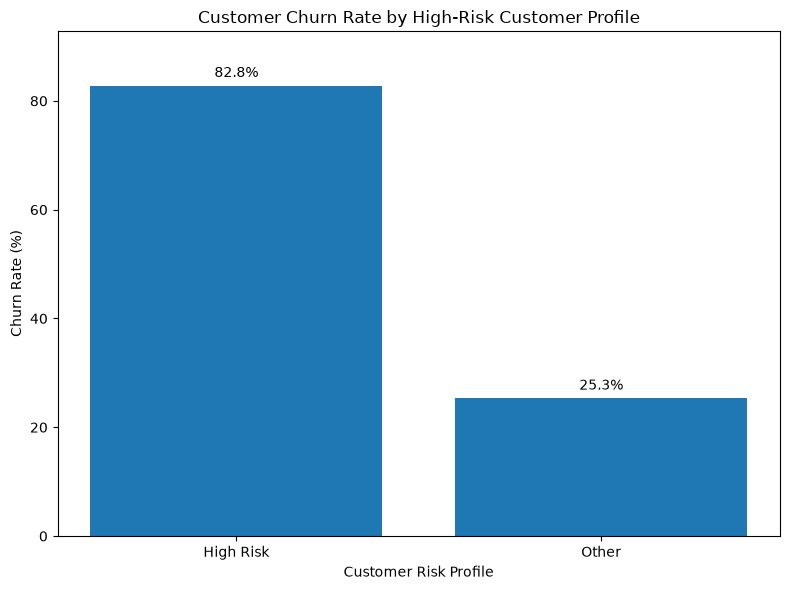

In [36]:
risk_churn = (
    df.groupby("HighRiskCustomer")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

risk_churn
# Calculate churn rate by customer risk profile
risk_churn = (
    df.groupby("HighRiskCustomer")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

# Create bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar(
    risk_churn.index,
    risk_churn.values
)

plt.xlabel("Customer Risk Profile")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by High-Risk Customer Profile")

# Add percentage labels above each bar
for bar, value in zip(bars, risk_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(risk_churn.values) + 10)
plt.tight_layout()
plt.show()

### Customer Churn Rate by High-Risk Customer Profile

The analysis reveals a substantial difference in churn rates between customers classified as **High Risk** and all other customers. Customers in the High Risk segment have a churn rate of **82.78%**, compared with **25.30%** among Other customers.

This means that more than four out of every five customers identified as High Risk have churned, while approximately one in four customers in the Other segment have churned. The High Risk segment therefore has a churn rate more than three times higher than the rest of the customer base.

The High Risk profile was created by combining several characteristics previously identified as being associated with customer churn: **month-to-month contracts, tenure of 12 months or less, high monthly charges, no Online Security, and no Tech Support**. The results demonstrate that these risk factors become particularly powerful when they occur together within the same customer profile.

### Business Insight

The findings suggest that customer churn is not driven by a single factor in isolation. Instead, customers who experience multiple risk characteristics simultaneously are substantially more vulnerable to churn.

The **High Risk Customer** segment represents a critical retention opportunity for the company. Although individual factors such as short tenure, month-to-month contracts, high monthly charges, and lack of additional services are each associated with churn, their combination identifies a customer group with an exceptionally high observed churn rate.

This provides the business with a practical approach to identifying customers who may require immediate retention attention rather than treating the entire customer base in the same way.

### Recommendation

The company should prioritize the High Risk Customer segment for proactive retention initiatives. These customers could be targeted with personalized interventions such as contract upgrade incentives, introductory discounts, improved technical support, relevant service bundles, and proactive customer engagement during the early stages of their relationship.

The company should also consider implementing a **customer risk monitoring system** that continuously identifies customers exhibiting multiple churn-risk characteristics. This would allow retention teams to intervene before customers decide to leave.

However, the High Risk classification used in this analysis is a **business rule created for exploratory analysis**, rather than a statistically validated predictive model. Further analysis should test the effectiveness of this risk profile on unseen data and investigate whether additional variables can improve the identification of customers at risk of churn.

In [41]:
df.to_csv(
    "../data/telecom_churn_feature_engineered.csv",
    index=False
)
print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.
